# Response API




* [/responses](https://docs.litellm.ai/docs/response_api)

> LiteLLM provides an endpoint in the spec of [OpenAI's /responses API](https://docs.litellm.ai/docs/response_api).


* [LiteLLM - Getting Started](https://docs.litellm.ai/docs/)
* [LiteLLM Cookbook](https://github.com/BerriAI/litellm/tree/main/cookbook)

# Setup

In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
import os
import json
import operator
from datetime import datetime, timedelta, timezone
from typing import (
    List, Dict, Any, Literal, Optional, Callable, Annotated
)

import regex as re
from pydantic import BaseModel, Field, ConfigDict
from tavily import TavilyClient
from langgraph.graph import StateGraph, START, END
import litellm
import mdformat
import trafilatura
from IPython.display import Markdown, display

## API Keys

In [3]:
path_to_openai_key:str = os.path.expanduser('~/.openai/api_key')
with open(path_to_openai_key, 'r', encoding='utf-8') as file:
    os.environ["OPENAI_API_KEY"] = file.read().strip()

path_to_tavily_key:str = os.path.expanduser('~/.tavily/api_key')
with open(path_to_tavily_key, 'r', encoding='utf-8') as file:
    os.environ["TAVILY_API_KEY"] = file.read().strip()

## Models

In [4]:
MODEL: str = "gpt-5.2"   # "openai/gpt-4o" 

# Open AI Response API Specification

* [API Reference](https://developers.openai.com/api/reference/resources/responses)
* [/openai/resources/responses/api.md](https://github.com/openai/openai-python/blob/main/src/openai/resources/responses/api.md)
* [OpenAI Python API library](https://github.com/openai/openai-python)

## Examples
* [examples/responses](https://github.com/openai/openai-python/tree/main/examples/responses)
* [Responses starter app](https://github.com/openai/openai-responses-starter-app)
> This repository contains a NextJS starter app built on top of the Responses API. It leverages built-in tools (web search and file search) and implements a chat interface with multi-turn conversation handling.



| API                                                                                                          | Desription                                                                                 |
|--------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------|
|[Create a model response](https://developers.openai.com/api/reference/resources/responses/methods/create)  |Creates a model response. Provide text or image inputs to generate text or JSON outputs. |
|[Get a model response](https://developers.openai.com/api/reference/resources/responses/methods/retrieve)   |Retrieves a model response with the given ID.|
|[Delete a model response](https://developers.openai.com/api/reference/resources/responses/methods/delete)  |Deletes a model response with the given ID.|
|[Cancel a response](https://developers.openai.com/api/reference/resources/responses/methods/cancel)        |Cancels a model response with the given ID. Only responses created with the background parameter set to true can be cancelled|
|[Compact a response](https://developers.openai.com/api/reference/resources/responses/methods/compact)      |Compact a conversation. Returns a compacted response object.|

 

## Reusable Prompt Templates

* [Reusable prompts](https://developers.openai.com/api/docs/guides/text#reusable-prompts)

> In the OpenAI dashboard, you can develop reusable prompts that you can use in API requests, rather than specifying the content of prompts in code. This way, you can more easily build and evaluate your prompts, and deploy improved versions of your prompts without changing your integration code.

## Built-in Tools

* [Using tools](https://developers.openai.com/api/docs/guides/tools?tool-type=web-search#available-tools)

```
const response = await client.responses.create({
    model: "gpt-5",
    tools: [
        { type: "web_search" },
    ],
    input: "What was a positive news story from today?",
});
```

* [ToolChoiceTypes](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(model)%20tool_choice_types%20%3E%20(schema))

```
file_search
web_search_preview
computer
computer_use_preview
computer_use
code_interpreter
image_generation
```

### File Search

* [File search](https://developers.openai.com/api/docs/guides/tools-file-search)

> This is a hosted tool managed by OpenAI, File search is a tool available in the Responses API. It enables models to retrieve information in a knowledge base of previously uploaded files through semantic and keyword search.
>
> ```
> from openai import OpenAI
> client = OpenAI()
> 
> response = client.responses.create(
>     model="gpt-4.1",
>     input="What is deep research by OpenAI?",
>     tools=[{
>         "type": "file_search",
>         "vector_store_ids": ["<vector_store_id>"]
>     }]
> )
> print(response)
> ```

* [Create vector store and upload files](https://developers.openai.com/api/docs/guides/retrieval)

> ```
> from openai import OpenAI
> client = OpenAI()
> 
> vector_store = client.vector_stores.create(        # Create vector store
>     name="Support FAQ",
> )
> 
> client.vector_stores.files.upload_and_poll(        # Upload file
>     vector_store_id=vector_store.id,
>     file=open("customer_policies.txt", "rb")
> )
> ```

> ```
> user_query = "What is the return policy?"
> 
> results = client.vector_stores.search(
>     vector_store_id=vector_store.id,
>     query=user_query,
> )
> ```

## Structured Output

* [How to use Structured Output in Open AI Response API Create Response](https://stackoverflow.com/a/79920359/4281353)
* [Structured model outputs](https://developers.openai.com/api/docs/guides/structured-outputs)

GPT-4o and later supports **Structured Outputs**. The model generates responses based on JSON Schema you define via Pydantic with:
1. function calling
2. json_schema response format

```
  "text": {
    "format": {
      "type": "json_schema"
      "strict": True,
      "schema": Schema.model_json_schema()
    }
  }
```

NOTE: JSON Scheema requires ```"additionalProperties": False``` for the response API to work for the Structured Output,

* [Structured model outputs - Supported schemas](https://developers.openai.com/api/docs/guides/structured-outputs#supported-schemas)

> Structured Outputs only supports generating specified keys / values, so we require developers to set ```additionalProperties: false``` to opt into Structured Outputs.


* [Schema additionalProperties must be false when strict is true](https://community.openai.com/t/schema-additionalproperties-must-be-false-when-strict-is-true/929996)

```
class OutputSchema(BaseModel):
    #--------------------------------------------------------------------------------
    # JSON Schema additionalProperty: False is required for the API to work
    # community.openai.com/t/schema-additionalproperties-must-be-false-when-strict-is-true/929996
    #--------------------------------------------------------------------------------
    # BadRequestError: Error code: 400 - {
    # {
    #   "message": "Invalid schema for response_format ... additionalProperties is required to be false.",
    #   "type": "invalid_request_error",
    #   "param": "text.format.schema",
    #   "code": "invalid_json_schema"
    # }
    #--------------------------------------------------------------------------------
    model_config = ConfigDict(extra="forbid")  
```

### Semantic Constraint

* [Supported properties](https://developers.openai.com/api/docs/guides/structured-outputs#supported-schemas)

> In addition to specifying the type of a property, you can specify a selection of additional constraints.
> ```additionalProperties: false``` must always be set in objects.
> ```additionalProperties``` controls whether it is allowable for an object to contain additional keys / values that were not defined in the JSON Schema.
> 
> Structured Outputs only supports generating specified keys / values, so we require developers to set ```additionalProperties: false``` to opt into Structured Outputs.

#### Supported string properties:

pattern — A regular expression that the string must match.
format — Predefined formats for strings. Currently supported:

* date-time
* time
* date
* duration
* email
* hostname
* ipv4
* ipv6
* uuid

####  Supported number properties:

* multipleOf — The number must be a multiple of this value.
* maximum — The number must be less than or equal to this value.
* exclusiveMaximum — The number must be less than this value.
* minimum — The number must be greater than or equal to this value.
* exclusiveMinimum — The number must be greater than this value.

Supported array properties:

* minItems — The array must have at least this many items.
* maxItems — The array must have at most this many items.


### Code Example

```
from openai import OpenAI
from pydantic import BaseModel

class OutputSchema(BaseModel):
    answer: str
    model_config = ConfigDict(extra="forbid")  


client = OpenAI()
response = client.responses.create(
    model=MODEL,
    instructions=system_role,
    input="How do I check if a Python object is an instance of a class?",
    text={
        "format": {
            "name": "OutputSchema",
            "type": "json_schema",
            "strict": True,
            "schema": OutputSchema.model_json_schema()
        }
    }
)
```

### JSON Schema ```additinalProperties```

```"additionalProperties": False``` is the feature of JSON Schema to declare there is no other properties in the schema. Pydantic add it with ```model_config = ConfigDict(extra="forbid")``` but there is no clear documentation.

* [Additional Properties](https://json-schema.org/understanding-json-schema/reference/object#additionalproperties)

> The additionalProperties keyword is used to control the handling of extra stuff, that is, properties whose names are not listed in the properties keyword or match any of the regular expressions in the patternProperties keyword. By default any additional properties are allowed.

* [explicit additionalProperties even when model_config["extra"] != "forbid" #6082](https://github.com/pydantic/pydantic/issues/6082)

> Currently additionalProperties in the model_schema is only set for "forbid".
Due to the evaluation of missing values to True is this correct, but I propose to declare additonalProperties for the other values of "extra" - "ignore", "allow" as well.

| Pydantic config | JSON Schema output |
|:---:|:---:|
| extra="forbid" | "additionalProperties": false |
| extra="allow" | "additionalProperties": true |
| extra="ignore" (default) | usually omitted (treated as allowed) |


---
# API

## Create a model response

### Request Boday Parameters

| Argument | Description | Note |
|---|---|---|
| [model](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20model%20%3E%20(schema)) | Model ID used to generate the response, like gpt-4o. |  |
| [instructions](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20instructions%20%3E%20(schema)) | A system (or developer) message inserted into the model's context. | Previously Role=System message |
| [input](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20input%20%3E%20(schema)) | optional string or array of EasyInputMessage or object or ResponseOutputMessage or 25 more Text, image, or file inputs to the model, used to generate a response. |  |
| [metadata](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20metadata%20%3E%20(schema)) | Set of 16 key-value pairs that can be attached to an object. This can be useful for storing additional information about the object in a structured format, and querying for objects via API or the dashboard. |  |
| [prompt](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20prompt%20%3E%20(schema)) | optional ResponsePrompt { id, variables, version }: Reference to a prompt template and its variables. [Learn more on Reusable prompts](https://developers.openai.com/docs/guides/text?api-mode=responses#reusable-prompts). |  |
| [reasoning](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20reasoning%20%3E%20(schema)) | Configuration options for reasoning models. Currently supported values are * none * minimal * low * medium * high * xhigh  Reducing reasoning effort can result in faster responses and fewer tokens used on reasoning in a response. |  |
| [tool_choice](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20tool_choice%20%3E%20(schema)) | "none" or "auto" or "required" |  |
| [tools](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20tools%20%3E%20(schema)) | An array of tools the model may call while generating a response. You can specify which tool to use by setting the tool_choice parameter. |  |
| [max_tool_calls](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20max_tool_calls%20%3E%20(schema)) | The maximum number of total calls to **built-in tools**. |  |
| [previous_response_id](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20previous_response_id%20%3E%20(schema)) | The unique ID of the previous response to the model. Use this to create multi-turn conversations. Learn more about conversation state. Cannot be used in conjunction with conversation. |  |
| [temperature](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20temperature%20%3E%20(schema)) | sampling temperature to use, between 0 and 2. Higher values like 0.8 will make the output more random |  |
| [text](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20text%20%3E%20(schema)) | Configuration options for a text response from the model. Can be plain text or structured JSON data. Configuring   The default format is ```{ "type": "text" }```. ```{ "type": "json_schema" }``` enables Structured Outputs, which ensures the model will match your supplied JSON schema. Learn more in the [Structured Outputs guide](https://developers.openai.com/api/docs/guides/structured-outputs). |  |
| [summary](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20reasoning%20%3E%20(schema)%20%2B%20(resource)%20%24shared%20%3E%20(model)%20reasoning%20%3E%20(schema)%20%3E%20(property)%20summary) | A summary of the reasoning performed by the model. This can be useful for debugging and understanding the model's reasoning process. One of auto, concise, or detailed. |  |
| [max_output_tokens](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20max_output_tokens%20%3E%20(schema)) |An upper bound for the number of tokens  |  |
| [parallel_tool_calls](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20parallel_tool_calls%20%3E%20(schema)) | Allow the model to run tool calls in parallel. |  |
| [stream](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20stream%20%3E%20(schema)) | model response data will be streamed to the client |  |
| [truncation](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(method)%20create%20%3E%20(params)%200.non_streaming%20%3E%20(param)%20truncation%20%3E%20(schema)) | * auto: If the input to this Response exceeds the model's context window size, the model will truncate the response to fit the context window by dropping items from the beginning of the conversation. * disabled (default): If the input size will exceed the context window size for a model, the request will fail with a 400 error. |  |
|  |  |  |

### Response Body Parameters

* [Response](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(model)%20response%20%3E%20(schema))

| Field | Type | Nullable | Description |
|---|---|---|---|
| `id` | string | No | Unique identifier for the response (e.g. `resp_...`) |
| `object` | string | No | Always `"response"` |
| `created_at` | integer | No | Unix timestamp (seconds) when the response was created |
| `status` | string | No | `"completed"`, `"in_progress"`, `"incomplete"`, `"failed"`, or `"cancelled"` |
| `model` | string | No | Model ID used to generate the response |
| `output` | array | No | Ordered list of output items (messages, tool calls, reasoning, etc.) |
| `previous_response_id` | string | Yes | ID of the prior response in a multi-turn conversation; `null` if first turn |
| `instructions` | string | Yes | System instructions passed to the model; `null` if not set |
| `max_output_tokens` | integer | Yes | Max output tokens allowed; `null` if unset |
| `temperature` | float | No | Sampling temperature (default `1.0`) |
| `top_p` | float | No | Nucleus sampling probability mass (default `1.0`) |
| `tool_choice` | string \| object | Yes | Tool selection mode: `"auto"`, `"none"`, `"required"`, or a specific tool object |
| `tools` | array | No | List of tool definitions available to the model |
| `parallel_tool_calls` | boolean | Yes | Whether parallel tool calls are enabled |
| `truncation` | string | Yes | Truncation strategy: `"auto"` or `"disabled"` |
| `reasoning` | object | Yes | Reasoning configuration (see below); `null` for non-reasoning models |
| `reasoning_effort` | string | Yes | Shorthand reasoning level: `"low"`, `"medium"`, `"high"` |
| `text` | object | Yes | Output text format configuration (see below) |
| `store` | boolean | No | Whether the response is persisted server-side (default `true`) |
| `metadata` | object | No | Up to 16 key-value pairs of custom metadata (keys ≤ 64 chars, values ≤ 512 chars) |
| `user` | string | Yes | Stable identifier for the end-user; `null` if not provided |
| `error` | object | Yes | Error details if the request failed; `null` otherwise |
| `incomplete_details` | object | Yes | Reason the response is incomplete; `null` if complete |
| `usage` | object | Yes | Token usage statistics; `null` when unavailable (e.g. streaming in progress) |


#### Output block

* [output: array of ResponseOutputItem](https://developers.openai.com/api/reference/resources/responses/methods/create#(resource)%20responses%20%3E%20(model)%20response%20%3E%20(schema)%20%3E%20(property)%20output)

The ```output``` is an array of items of types:

```
response
└── output[]               ← array of items, in order of execution
  ├── { type: "message", ... }
  ├── { type: "function_call", ... }
  ├── { type: "function_call_output", ... }
  ├── { type: "reasoning", ... }
  ├── { type: "web_search_call", ... }
  ├── { type: "file_search_call", ... }
  └── { type: "computer_call", ... }      
```

Example:

> ```
> "output": [
>     {
>       "type": "message",     # <--- message type
>       "id": "msg_67ccd2bf17f0819081ff3bb2cf6508e60bb6a6b452d3795b",
>       "status": "completed",
>       "role": "assistant",
>       "content": [
>         {
>           "type": "output_text",
>           "text": "In a peaceful grove beneath a silver moon, a unicorn named Lumina discovered a hidden pool.",
>           "annotations": []
>         }
>       ]
>     }
> ]
> ```

```
"message" Type
┌─────────┬─────────────┬────────────────────────────────────────────────────────┐
│  Field  │    Type     │                      Description                       │
├─────────┼─────────────┼────────────────────────────────────────────────────────┤
│ id      │ string      │ Message identifier                                     │
├─────────┼─────────────┼────────────────────────────────────────────────────────┤
│ type    │ "message"   │ Item type discriminator                                │
├─────────┼─────────────┼────────────────────────────────────────────────────────┤
│ role    │ "assistant" │ Always "assistant" for model output                    │
├─────────┼─────────────┼────────────────────────────────────────────────────────┤
│ status  │ string      │ "completed", "in_progress", or "incomplete"            │
├─────────┼─────────────┼────────────────────────────────────────────────────────┤
│ content │ array       │ Array of content blocks (see content item types below) │
└─────────┴─────────────┴────────────────────────────────────────────────────────┘

"reasoning" Type
┌───────────────────┬───────────────┬─────────────────────────────────────────────────────────────────────────────┐
│       Field       │     Type      │                                 Description                                 │
├───────────────────┼───────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ id                │ string        │ Reasoning item identifier                                                   │
├───────────────────┼───────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ type              │ "reasoning"   │ Item type                                                                   │
├───────────────────┼───────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ summary           │ array         │ Array of summary text objects (populated when reasoning.summary is enabled) │
├───────────────────┼───────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ encrypted_content │ string        │ Encrypted chain-of-thought (opaque; for pass-through only)                  │
├───────────────────┼───────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ status            │ string | null │ Completion status                                                           │
└───────────────────┴───────────────┴─────────────────────────────────────────────────────────────────────────────┘

"function_call" type
┌───────────┬─────────────────┬──────────────────────────────────────────────┐
│   Field   │      Type       │                 Description                  │
├───────────┼─────────────────┼──────────────────────────────────────────────┤
│ id        │ string          │ Output item identifier                       │
├───────────┼─────────────────┼──────────────────────────────────────────────┤
│ type      │ "function_call" │ Item type                                    │
├───────────┼─────────────────┼──────────────────────────────────────────────┤
│ call_id   │ string          │ Unique ID to match this call with its output │
├───────────┼─────────────────┼──────────────────────────────────────────────┤
│ name      │ string          │ Function name                                │
├───────────┼─────────────────┼──────────────────────────────────────────────┤
│ arguments │ string          │ JSON-encoded argument string                 │
├───────────┼─────────────────┼──────────────────────────────────────────────┤
│ status    │ string          │ "completed" or "in_progress"                 │
└───────────┴─────────────────┴──────────────────────────────────────────────┘

"function_call_output" type
┌─────────┬────────────────────────┬────────────────────────────────────────────────────────┐
│  Field  │          Type          │                      Description                       │
├─────────┼────────────────────────┼────────────────────────────────────────────────────────┤
│ id      │ string                 │ Output item identifier                                 │
├─────────┼────────────────────────┼────────────────────────────────────────────────────────┤
│ type    │ "function_call_output" │ Item type                                              │
├─────────┼────────────────────────┼────────────────────────────────────────────────────────┤
│ call_id │ string                 │ Matches the call_id of the corresponding function_call │
├─────────┼────────────────────────┼────────────────────────────────────────────────────────┤
│ output  │ string                 │ Result returned by the tool                            │
├─────────┼────────────────────────┼────────────────────────────────────────────────────────┤
│ status  │ string                 │ "completed"                                            │
└─────────┴────────────────────────┴────────────────────────────────────────────────────────┘

"web_search_call" type
┌────────┬───────────────────┬────────────────────────────────┐
│ Field  │       Type        │          Description           │
├────────┼───────────────────┼────────────────────────────────┤
│ id     │ string            │ Item identifier                │
├────────┼───────────────────┼────────────────────────────────┤
│ type   │ "web_search_call" │ Item type                      │
├────────┼───────────────────┼────────────────────────────────┤
│ status │ string            │ "completed", "searching", etc. │
└────────┴───────────────────┴────────────────────────────────┘

"file_search_call" type
┌─────────┬────────────────────┬───────────────────────────────────────────────────────────────────────────────┐
│  Field  │        Type        │                                  Description                                  │
├─────────┼────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ id      │ string             │ Item identifier                                                               │
├─────────┼────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ type    │ "file_search_call" │ Item type                                                                     │
├─────────┼────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ queries │ array              │ Search queries issued                                                         │
├─────────┼────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ results │ array | null       │ Matched file chunks (only present when include: ["file_search_call.results"]) │
├─────────┼────────────────────┼───────────────────────────────────────────────────────────────────────────────┤
│ status  │ string             │ "completed"                                                                   │
└─────────┴────────────────────┴───────────────────────────────────────────────────────────────────────────────┘

"computer_call" type
┌───────────────────────┬─────────────────┬────────────────────────────────────────────────────────────────┐
│         Field         │      Type       │                          Description                           │
├───────────────────────┼─────────────────┼────────────────────────────────────────────────────────────────┤
│ id                    │ string          │ Item identifier                                                │
├───────────────────────┼─────────────────┼────────────────────────────────────────────────────────────────┤
│ type                  │ "computer_call" │ Item type                                                      │
├───────────────────────┼─────────────────┼────────────────────────────────────────────────────────────────┤
│ call_id               │ string          │ Unique call reference                                          │
├───────────────────────┼─────────────────┼────────────────────────────────────────────────────────────────┤
│ action                │ object          │ The computer action to perform (click, type, screenshot, etc.) │
├───────────────────────┼─────────────────┼────────────────────────────────────────────────────────────────┤
│ pending_safety_checks │ array           │ Safety checks awaiting acknowledgment                          │
├───────────────────────┼─────────────────┼────────────────────────────────────────────────────────────────┤
│ status                │ string          │ "completed" or "in_progress"                                   │
└───────────────────────┴─────────────────┴────────────────────────────────────────────────────────────────┘
```

---

# Get Started

* [Run an API Call (Python)](https://developers.openai.com/api/docs/quickstart?language=python#install-the-openai-sdk-and-run-an-api-call)


## Create API

```
curl https://api.openai.com/v1/responses \
  -H "Content-Type: application/json" \
  -H "Authorization: Bearer $OPENAI_API_KEY" \
  -d '{
    "model": "gpt-5.4",
    "instructions": "You are a helpful assistant.",
    "input": "Hello!",
    "stream": true
  }'
```

In [5]:
from openai import OpenAI
client = OpenAI()

In [35]:
class PythonSyntax(BaseModel):
    """Schema for the Python query answer"""
    specification: list[str] = Field(
        description="Python specifications referred to for the answer"
    )
    uri: list[str] = Field(
        description="URIs of the specifications referred"
    )
    answer: str = Field(
        description="Final answer to the query"
    )
    note: str = Field(
        description="Additional notes or clarifications"
    )
    #--------------------------------------------------------------------------------
    # JSON Schema additionalProperty: False is required for the API to work
    # community.openai.com/t/schema-additionalproperties-must-be-false-when-strict-is-true/929996
    #--------------------------------------------------------------------------------
    # BadRequestError: Error code: 400 - {
    # {
    #   "message": "Invalid schema for response_format ... additionalProperties is required to be supplied and to be false.",
    #   "type": "invalid_request_error",
    #   "param": "text.format.schema",
    #   "code": "invalid_json_schema"
    # }
    #--------------------------------------------------------------------------------
    model_config = ConfigDict(extra="forbid")  # adds additionalProperties: false

PythonSyntax.model_json_schema()

{'additionalProperties': False,
 'description': 'Schema for the Python query answer',
 'properties': {'specification': {'description': 'Python specifications referred to for the answer',
   'items': {'type': 'string'},
   'title': 'Specification',
   'type': 'array'},
  'uri': {'description': 'URIs of the specifications referred',
   'items': {'type': 'string'},
   'title': 'Uri',
   'type': 'array'},
  'answer': {'description': 'Final answer to the query',
   'title': 'Answer',
   'type': 'string'},
  'note': {'description': 'Additional notes or clarifications',
   'title': 'Note',
   'type': 'string'}},
 'required': ['specification', 'uri', 'answer', 'note'],
 'title': 'PythonSyntax',
 'type': 'object'}

In [36]:
system_role: str = """
You are a meticulous coding assistant who does not answer without verifying the code with the Python specifications.
You reply the answer in the given Python JSON schema including:
* specificaition: Specification reference such as PEP 8.
* uri: URI of the specification
* answer: reply to the inquiry
* note: any other information for the note.
"""

response = client.responses.create(
    model=MODEL,
    instructions=system_role,
    input="How do I check if a Python object is an instance of a class?",
    tools=[
        { "type": "web_search" }
    ],
    tool_choice="required",
    metadata={
        "user_id": "oonisim",
        "internal_project_id": "scribe",
        "session_type": "personal"
    },
    temperature=0,
    max_output_tokens=1024,
    text={
        "format": {
            "name": "PythonSyntax",
            "type": "json_schema",
            "strict": True,
            "schema": PythonSyntax.model_json_schema()
        }
    },
    stream=False
)

In [37]:
print(response.model_dump_json(indent=4))

{
    "id": "resp_03f83632d508587f0069d2069d60dc819191bb5d209b48a4a0",
    "created_at": 1775371933.0,
    "error": null,
    "incomplete_details": null,
    "instructions": "\nYou are a meticulous coding assistant who does not answer without verifying the code with the Python specifications.\nYou reply the answer in the given Python JSON schema including:\n* specificaition: Specification reference such as PEP 8.\n* uri: URI of the specification\n* answer: reply to the inquiry\n* note: any other information for the note.\n",
    "metadata": {
        "user_id": "oonisim",
        "internal_project_id": "scribe",
        "session_type": "personal"
    },
    "model": "gpt-5.2-2025-12-11",
    "object": "response",
    "output": [
        {
            "id": "ws_03f83632d508587f0069d2069db7ac8191845fe8cc20c3edab",
            "action": {
                "query": "Python isinstance built-in function documentation",
                "type": "search",
                "queries": [
           

---
# LiteLLM Facade - Response API

* [OpenAI - Migrate to Responses API](https://developers.openai.com/api/docs/guides/migrate-to-responses)
* [LiteLLM - OpenAI - Response API](https://docs.litellm.ai/docs/providers/openai/responses_api)

```
import litellm

response = litellm.responses(
    model="openai/gpt-5",
    input="What is the capital of France?",
    tools=[{
        "type": "web_search_preview",
        "search_context_size": "medium"  # Options: "low", "medium", "high"
    }]
)
```

LiteLLM supports the OpenAI **Response API** via `litellm.responses()`.

| Concept            | Response API (current)                            |
|--------------------|---------------------------------------------------|
| LiteLLM call       | `litellm.responses()`                             |
| Input key          | `input=`                                          |
| System prompt      | `instructions=` param                             |
| Tool definition    | Flat `{name, desc, params}`                       |
| Tool call location | `response.output` items (`type=="function_call"`) |
| Tool call ID field | `call_id`                                         |
| Tool result format | `type="function_call_output"` + `output=`         |
| Final text         | `response.output_text`                            |



In [9]:
def call_llm(
    input: List[Any],                              # Chat Completion: messages= (List[Dict] with role/content)
                                                   # Response API:    input= (string OR List of input items)
    tools: Optional[List[Dict[str, Any]]] = None,
    stream: bool = False,
    model: str = MODEL,
    instructions: Optional[str] = None,            # Response API: replaces {"role":"system"} in messages
                                                   # Ref: https://developers.openai.com/api/reference/resources/responses/methods/create
):
    # Chat Completion (deprecated):
    #   litellm.completion(model, messages, tools, stream)
    #   Returns: ChatCompletion -> response.choices[0].message.content / .tool_calls
    #   Ref: https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create
    #
    # Response API:
    #   litellm.responses(model, input, tools, stream, instructions)
    #   Returns: Response -> response.output (typed Items list), response.output_text (helper)
    #   Ref: https://docs.litellm.ai/docs/providers/openai/responses_api
    try:
        response = litellm.responses(
            model=model,
            input=input,
            tools=tools,
            stream=stream,
            instructions=instructions,
        )
        return response
    except litellm.AuthenticationError as e:
        raise RuntimeError(f"Authentication failed: {e}") from e
    except litellm.RateLimitError as e:
        raise RuntimeError(f"Rate limited: {e}") from e
    except litellm.APIError as e:
        raise RuntimeError(f"API error: {e}") from e


## Batch

In constrat to **streaming**, send a one-off request to get one-off reply.

In [10]:
response = call_llm(input=[{
    "role": "user",
    "content": "Hello, how are you?"
}])
# Response API:    response.output_text  (convenience helper)
# Chat Completion: response.choices[0].message.content
print(response.output_text)
print(json.dumps(response.model_dump(), indent=4, default=str))
del response

Hello! I’m here and ready to help. How can I assist you today?
{
    "id": "resp_bGl0ZWxsbTpjdXN0b21fbGxtX3Byb3ZpZGVyOm9wZW5haTttb2RlbF9pZDpOb25lO3Jlc3BvbnNlX2lkOnJlc3BfMDMzMWM4YmMzYTE5MzU3NTAwNjlkMjA0NjgzNzdjODE5MWJkZWEyMGJkZGE3MzU2MzU=",
    "created_at": 1775371368,
    "error": null,
    "incomplete_details": null,
    "instructions": null,
    "metadata": {},
    "model": "gpt-5.2-2025-12-11",
    "object": "response",
    "output": [
        {
            "id": "msg_0331c8bc3a1935750069d20468b70481918899142214a3ae69",
            "content": [
                {
                    "annotations": [],
                    "text": "Hello! I\u2019m here and ready to help. How can I assist you today?",
                    "type": "output_text",
                    "logprobs": []
                }
            ],
            "role": "assistant",
            "status": "completed",
            "type": "message",
            "phase": null
        }
    ],
    "parallel_tool_calls": true,
   

## Streaming

In [11]:
response = call_llm(
    input=[{"role": "user", "content": "Hello, how are you?"}],
    stream=True
)

# Response API streaming: event-driven with typed events
# Chat Completion streaming: chunk.choices[0].delta.content
# Ref: https://docs.litellm.ai/docs/providers/openai/responses_api#streaming
for event in response:
    # Response API:    event.type == 'response.output_text.delta'  ->  event.delta
    # Chat Completion: chunk.choices[0].delta.content
    if event.type == 'response.output_text.delta':
        print(event.delta, end="", flush=True)

print()
del response

I’m doing well, thanks. How can I help you today?


/Users/oonisim/venv/llm/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `ResponseAPIUsage` - serialized value may not be as expected [field_name='usage', input_value={'completion_tokens': 18,..., 'image_tokens': None}}, input_type=dict])
  return self.__pydantic_serializer__.to_python(


---
# Tool Calling Protocol


## OpenAI API Specification


OpenAI defined the **Function (Tool) Calling Protocol** as in [Function calling](https://developers.openai.com/api/docs/guides/function-calling). 

  1. LLM responds with role: "assistant" message containing tool_calls (with id, function.name, function.arguments)
  2. You execute the tools                                                      
  3. You send back one message per tool call with role: "tool", tool_call_id matching the original id, and content containing the result as a string

There are six stages in the Protocol.

1. Tool Definition by Application and Declaration to LLM at Prompt Message
> When we make an API request to the model with a prompt, we can include a list of tools the model could consider using.

2. Tool Call Decision by LLM  (**Reasoing** and **Decisoning**)
> tool call refers to a special kind of decision response from LLM to call one of the tools to execute the prompt given.
   
3. Tool Execution by Application
4. Tool Output Usage by LLM
> tool call output refers to the response a tool generates using the input from a model’s tool call. We send **all of the tool definition, the original prompt, the model’s tool call, and the tool call output back** to LLM to finally receive a text response.

5. LLM completes the prompt

### Tool Calling Workflow

```
1. Application to LLM
   │ Define and Declare Tools in the prompt
   ▼
2. LLM
   │ Reason/Decide Tool Calls
   ▼
3. Application/Orchestration
   │ Tool Executions
   ▼
4. LLM Receives Tool Outputs
   │ Use Tool Outputs
   ▼
5. LLM Complete the prompt
```

<img src="image/tool_call_flow.png" align="left" width=500/>



## LiteLLM

Use LiteLLM as the wrapper for the OpenAI Response API for Function calling.

* [LiteLLM - Response API](https://docs.litellm.ai/docs/providers/openai/responses_api)
* [LiteLLM - Function Calling](https://docs.litellm.ai/docs/completion/function_call)

1. `litellm.responses()` with `tools=` and `instructions=`
2. Parse `response.output` for `type=="function_call"` items and execute functions
3. Second `litellm.responses()` call with tool results appended to `input`


## Tool Definition

* [Defining Functions (Tools)](https://developers.openai.com/api/docs/guides/function-calling#defining-functions)

First, you define a tool based on the OpenAI definition. This is what LiteLLM accepts as well.

| Field       | Description                                          |
|-------------|------------------------------------------------------|
| type        | This should always be function                       |
| name        | The function’s name (e.g. get_weather)               |
| description | Details on when and how to use the function          |
| parameters  | JSON schema defining the function’s input arguments  |
| strict      | Whether to enforce strict mode for the function call |


### Tool Definition Format

The tool definition format differs between Chat Completion and Response API:

**Chat Completion (deprecated)** — nested `"function"` wrapper:
```
{
  "type": "function",
  "function": {              ← extra nesting layer
     "name": "...",
     "description": "...",
     "parameters": { JSON schema }
  }
}
```

**Response API** — flat, no nested `"function"` wrapper:
```
{
  "type": "function",
  "name": "...",             ← promoted to top level
  "description": "...",
  "parameters": { JSON schema }
}
```

* [Response API - Function Calling](https://developers.openai.com/api/docs/guides/function-calling)

**Example (Response API):**
```
{
  "type": "function",
  "name": "get_weather",
  "description": "Retrieves current weather for the given location.",
  "parameters": {
    "type": "object",
    "properties": {
      "location": {
        "type": "string",
        "description": "City and country e.g. Bogota, Colombia"
      },
      "units": {
        "type": "string",
        "enum": ["celsius", "fahrenheit"],
        "description": "Units the temperature will be returned in."
      }
    },
    "required": ["location", "units"],
    "additionalProperties": false
  },
  "strict": true
}
```

### Namespace

* [Defining namespace](https://developers.openai.com/api/docs/guides/function-calling#defining-namespaces)

> Namespaces help organize similar tools and are especially useful when the model must choose between tools that serve different systems or purposes.

```
{
  "type": "namespace",
  "name": "crm",
  "description": "CRM tools for customer lookup and order management.",
  "tools": [
      tool_definition+
 ]
}
```


### Tool Parameter JSON Schema

[Pydantic JSON Schema](https://docs.pydantic.dev/latest/concepts/json_schema/) to generate the JSON Schema for the Tool Definition. 

For the Tool Definition for the [Tavilty Search](https://docs.tavily.com/sdk/python/reference#tavily-search):


#### Tool 

In [12]:
# Function for the Search Tool
search_tool: Callable = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
if not hasattr(search_tool, "tool_name"):
    search_tool.name = "search_tool"

name_to_tool: Dict[str, Callable] = {
    # search_tool.name: search_tool.search
    search_tool.name: search_tool.search
}

#### Tool Parameters

Use Pydantic to generate the JSON Schema for the parameters.

In [13]:
# Parameters for the Search Tool
class SearchToolParameters(BaseModel):
    """
    Search the web for current events, news, or deep research.
    """
    query: str = Field(description="The search query to look up")
    
    topic: Literal["general", "news", "finance"] = Field(
        default="general",
        description="Category of search. Use 'news' for current events/politics, 'finance' for market data."
    )
    
    search_depth: Literal["basic", "advanced"] = Field(
        default="basic",
        description="Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context."
    )
    
    time_range: Optional[Literal["day", "week", "month", "year"]] = Field(
        default=None,
        description="Filter results by publication date. Especially useful with topic='news'."
    )
    
    max_results: int = Field(
        default=5, ge=1, le=10,
        description="Number of search results to return."
    )

In [14]:
search_tool_parameters: Dict[str, Any] = SearchToolParameters.model_json_schema()
print(json.dumps(search_tool_parameters, indent=2, default=str))

{
  "description": "Search the web for current events, news, or deep research.",
  "properties": {
    "query": {
      "description": "The search query to look up",
      "title": "Query",
      "type": "string"
    },
    "topic": {
      "default": "general",
      "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
      "enum": [
        "general",
        "news",
        "finance"
      ],
      "title": "Topic",
      "type": "string"
    },
    "search_depth": {
      "default": "basic",
      "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
      "enum": [
        "basic",
        "advanced"
      ],
      "title": "Search Depth",
      "type": "string"
    },
    "time_range": {
      "anyOf": [
        {
          "enum": [
            "day",
            "week",
            "month",
            "year"
          ],
          "type": "string"
        },
        {
       

#### Tool Description

In [15]:
search_tool_description: str = SearchToolParameters.__doc__.strip()
print(search_tool_description)

Search the web for current events, news, or deep research.


### Tool Definition of the Tabiliy Web Search

In [16]:
# Response API: flat tool definition (name/description/parameters at top level)
# Chat Completion: nested under "function" key -> {"type":"function","function":{"name":...}}
# Ref: https://developers.openai.com/api/docs/guides/function-calling
search_tool_definition = {
    "type": "function",
    "name": search_tool.name,                # Chat Completion: nested as "function.name"
    "description": search_tool_description,  # Chat Completion: nested as "function.description"
    "parameters": search_tool_parameters,    # Chat Completion: nested as "function.parameters"
}
print(json.dumps(search_tool_definition, indent=2, default=str))

{
  "type": "function",
  "name": "search_tool",
  "description": "Search the web for current events, news, or deep research.",
  "parameters": {
    "description": "Search the web for current events, news, or deep research.",
    "properties": {
      "query": {
        "description": "The search query to look up",
        "title": "Query",
        "type": "string"
      },
      "topic": {
        "default": "general",
        "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
        "enum": [
          "general",
          "news",
          "finance"
        ],
        "title": "Topic",
        "type": "string"
      },
      "search_depth": {
        "default": "basic",
        "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
        "enum": [
          "basic",
          "advanced"
        ],
        "title": "Search Depth",
        "type": "string"
      },
      "time_ra

## Tool Declaration

You declare the **tool definitions** to the LLM.

**Response API** — flat format:
```
tools = [
    {
      "type": "function",
      "name": "SearchTool",
      "description": "...",
      "parameters": { JSON Schema }
    },
    ...
]
```

**Chat Completion (deprecated)** — nested `"function"` wrapper:
```
tools = [
    {
      "type": "function",
      "function": {
        "name": "SearchTool",
        "description": "...",
        "parameters": { JSON Schema }
      }
    },
    ...
]
```

* [LiteLLM - Response API](https://docs.litellm.ai/docs/providers/openai/responses_api)

```python
# Response API
response = litellm.responses(
    model=model,
    input=input,
    tools=tools,            # <- declare tools here (flat format)
    instructions=instructions,
)
```

*Example input:*
```
{
  "model": "openai/gpt-4o",
  "input": [
    {
        "role": "user",
        "content": "Weather in Tokyo?"
    }
  ],
  "tools": [
    {
      "type": "function",
      "name": "get_weather",
      "parameters": {
        "type": "object",
        "properties": {
          "location": {"type": "string"}
        }
      }
    }
  ]
}
```


### Tool Declartion for the Search

In [17]:
tool_declarations: List[Dict[str, Any]] = [
    search_tool_definition
]

### Input to LLM

Build the input items to LLM (the prompt).

* Response API: `input=` takes a list of message dicts `{role, content}`
* System instructions are passed separately as `instructions=`


In [18]:
# Response API: system instructions go in the instructions= parameter (not in input items)
# Chat Completion: {"role": "system", "content": "..."} was the first element of messages
# Ref: https://developers.openai.com/api/docs/guides/migrate-to-responses#system-and-developer-messages
SYSTEM_INSTRUCTIONS: str = """
You are a helpful assistant. Use tools when needed.
Verify the relevance of retrieved results before using them, and apply an intelligent
intent filter so you keep only the news items that align with the user inquiry.
Only report items that are relevant to the user request and supported by the tool output.
If the search results are noisy or insufficient, say that and do not infer missing facts.
"""

# Response API: input= contains only user/assistant turn items (no system message)
# Chat Completion: messages= contained system + user messages together
input_prompt: List[Dict[str, str]] = [
    {
        "role": "user",      # <--- same role as before
        "content": "What are the top news headlines in AI from the last week?"
    }
]

### LLM Call


In [19]:
response_to_prompt = call_llm(
    input=input_prompt,                    # Chat Completion: messages=messages_prompt
    tools=tool_declarations,
    instructions=SYSTEM_INSTRUCTIONS,      # Chat Completion: included in messages as role="system"
)
print(json.dumps(response_to_prompt.model_dump(), indent=4, default=str))

{
    "id": "resp_bGl0ZWxsbTpjdXN0b21fbGxtX3Byb3ZpZGVyOm9wZW5haTttb2RlbF9pZDpOb25lO3Jlc3BvbnNlX2lkOnJlc3BfMDVkNjc0YTFkMzAwMTFkODAwNjlkMjA0NmI5MmUwODE5Nzk1YzZiNDU4MTYwMTdlZjk=",
    "created_at": 1775371371,
    "error": null,
    "incomplete_details": null,
    "instructions": "\nYou are a helpful assistant. Use tools when needed.\nVerify the relevance of retrieved results before using them, and apply an intelligent\nintent filter so you keep only the news items that align with the user inquiry.\nOnly report items that are relevant to the user request and supported by the tool output.\nIf the search results are noisy or insufficient, say that and do not infer missing facts.\n",
    "metadata": {},
    "model": "gpt-5.2-2025-12-11",
    "object": "response",
    "output": [
        {
            "arguments": "{\"query\":\"top AI news headlines last week\",\"topic\":\"news\",\"search_depth\":\"advanced\",\"time_range\":\"week\",\"max_results\":10}",
            "call_id": "call_8jzrmC1fn

## LLM Tool Calls

### Tool call handling logic

* [OpenAI - Handling function calls](https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls)

**Response API** — tool calls are Items in `response.output` with `type == "function_call"`:

```python
for item in response.output:
    if item.type != "function_call":
        continue
    name = item.name
    args = json.loads(item.arguments)
    result = call_function(name, args)
    input_items.append({
        "type": "function_call_output",  # <- NOT role="tool"
        "call_id": item.id,              # <- NOT tool_call_id
        "output": str(result)            # <- NOT content
    })
```

**Chat Completion (deprecated)** — tool calls in `response.choices[0].message.tool_calls`:
```python
for tool_call in response.choices[0].message.tool_calls:
    # tool_call.id, tool_call.function.name, tool_call.function.arguments
    messages.append({"role": "tool", "tool_call_id": tool_call.id, "content": result})
```


### Tool Calls

**Response API**: the tool call is a top-level Item in `response.output`:

```
{
  "type": "function_call",
  "id": "call_JVHGxhAhxbmAlwiDkuc7fXk6",    <- call_id (used in function_call_output)
  "name": "search_tool",
  "arguments": "{\"query\":\"AI news\",\"topic\":\"news\",\"search_depth\":\"basic\"}"
}
```

**Chat Completion (deprecated)** wrapped this inside `choices[0].message.tool_calls`:
```
"message": {
    "role": "assistant",
    "tool_calls": [
        {
            "id": "call_JVHGxhAhxbmAlwiDkuc7fXk6",  <- tool_call_id
            "type": "function",
            "function": {
                "name": "search_tool",
                "arguments": "{\"query\":\"AI news\",...}"
            }
        }
    ]
}
```


In [20]:
# Response API: check response.output is non-empty
# Chat Completion: checked "choices" in response.model_dump()
assert response_to_prompt.output, \
    f"Expected non-empty output:\n{json.dumps(response_to_prompt.model_dump(), indent=2, default=str)}"


In [21]:
def extract_tool_calls(response) -> List[Any]:
    """Extract function_call items from a Response API response.

    Response API: tool calls are Items in response.output with type == "function_call"
      Each item has: .type, .id (call_id), .name, .arguments (JSON string)
      Ref: https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls

    Chat Completion equivalent:
      response.choices[0].message.tool_calls
      Each: .id, .function.name, .function.arguments
    """
    return [item for item in response.output if item.type == "function_call"]


In [22]:
def in_time_window(result: Dict[str, Any], query: str, now: datetime) -> bool:
    """Return True when the result was published within the last month."""
    del query  # Reserved for query-aware time parsing later.
    published_date = result.get("published_date")
    if not published_date:
        return False
    try:
        published_at = datetime.strptime(
            published_date, "%a, %d %b %Y %H:%M:%S %Z"
        ).replace(tzinfo=timezone.utc)
    except ValueError:
        return False
    return published_at >= (now - timedelta(days=30))

def is_bad_page_type(result: Dict[str, Any]) -> bool:
    """Return True for page types that are poor RAG evidence for this tutorial."""
    negative_markers = ('/event/', 'event', 'retreat', 'viewership', '/journalism/')
    title = str(result.get("title", "")).lower()
    url = str(result.get("url", "")).lower()
    return any(marker in title or marker in url for marker in negative_markers)

def keep_result(query: str, result: Dict[str, Any], now: datetime) -> bool:
    """Return True when a Tavily result is usable for the final answer."""
    if not in_time_window(result, query, now):
        return False
    if is_bad_page_type(result):
        return False
    if float(result.get("score", 0.0)) < 0.85:
        return False
    return True

def filter_search_results(results: List[Dict[str, Any]], query: str) -> List[Dict[str, Any]]:
    """Keep only search hits that are recent, relevant, and usable."""
    now = datetime.now(timezone.utc)
    return [result for result in results if keep_result(query, result, now)]

def format_search_result(result: Dict[str, Any]) -> str:
    """Serialize one Tavily result as JSON for the tool response."""
    payload = {
        "title": result.get("title", ""),
        "url": result.get("url", ""),
        "content": result.get("content", ""),
        "published_date": result.get("published_date"),
    }
    return json.dumps(payload, ensure_ascii=False)

def execute_tool_calls(tool_calls: List[Any]) -> List[Dict[str, Any]]:
    """Execute function_call items and return function_call_output items.

    Args:
        tool_calls: function_call items from response.output
                    Each has: .type, .id, .name, .arguments (JSON string)
    Returns:
        List of function_call_output dicts for the Response API input:
        [{"type": "function_call_output", "call_id": ..., "output": ...}]

    Response API output format:
        {"type": "function_call_output", "call_id": ..., "output": ...}
    Chat Completion equivalent:
        {"role": "tool", "tool_call_id": ..., "name": ..., "content": ...}
    Ref: https://developers.openai.com/api/docs/guides/function-calling#formatting-results
    """
    _tool_outputs: List[Dict[str, Any]] = []
    for tool_call in tool_calls:
        if tool_call.type != "function_call":
            continue

        func_name: str = tool_call.name                              # Chat Completion: tool_call.function.name
        func_args: Dict[str, Any] = json.loads(tool_call.arguments)  # Chat Completion: tool_call.function.arguments
        execution: Any = name_to_tool[func_name](**func_args)
        results = execution.get("results", [])
        if func_name == "search_tool":
            results = filter_search_results(results=results, query=func_args.get("query", ""))
        if not results:
            content = json.dumps({
                "query": func_args.get("query", ""),
                "results": [],
                "note": "No clearly relevant search results were found. Ask for a narrower query or different source."
            }, ensure_ascii=False)
        else:
            content = json.dumps({
                "query": func_args.get("query", ""),
                "results": [json.loads(format_search_result(r)) for r in results]
            }, ensure_ascii=False)

        _tool_outputs.append({
            "type": "function_call_output",  # Response API (Chat Completion: no "type", role="tool")
            "call_id": tool_call.call_id,     # Response API: call_id (NOT .id which is the item ID)
            # tool_call.id = item-level ID (e.g. fc_077c...)
            # tool_call.call_id = tool call reference ID (e.g. call_abc...) -- use this
            "output": content,               # Response API: output   (Chat Completion: content)
        })

    return _tool_outputs


In [23]:
import markdown
from html.parser import HTMLParser

class _StripHTML(HTMLParser):
    """Extract plain text from HTML, used as fallback in render_content."""
    def __init__(self):
        super().__init__()
        self._parts = []
    def handle_data(self, data):
        self._parts.append(data)
    def get_text(self) -> str:
        return ''.join(self._parts)

def render_content(content: str, url: str) -> str:
    """Return clean plain text from url for display(Markdown(...)).
    Fetches original article text via trafilatura (preferred).
    Falls back to parsing the Tavily markdown snippet via the markdown
    package to strip heading/formatting artifacts.
    Args:
        content: Tavily markdown snippet (fallback source).
        url:     Original article URL (preferred source).
    """
    if url:
        downloaded = trafilatura.fetch_url(url)
        fetched = trafilatura.extract(downloaded) if downloaded else None
        if fetched:
            return fetched.replace('\xa0', ' ')
    # Fallback: markdown → HTML → strip tags → plain text
    html = markdown.markdown(content)
    extractor = _StripHTML()
    extractor.feed(html)
    return extractor.get_text().replace('\xa0', ' ')


In [24]:
def show_tool_executions(outputs: List[Dict[str, Any]]) -> None:
    """Display tool execution results.
    Parses JSON tool payloads and calls render_content(content, url)
    to fetch clean article text for display.
    """
    for msg in outputs:
        # Response API: tool result key is "output"    -> {"type":"function_call_output","call_id":...,"output":"..."}
        # Chat Completion: tool result key was "content" -> {"role":"tool","tool_call_id":...,"content":"..."}
        payload = json.loads(msg.get("output", msg.get("content", "{}")))
        results = payload.get("results", [])
        if not results:
            note = payload.get("note", "No tool results to display.")
            display(Markdown(note))
            continue
        for result in results:
            source = result.get("title", "")
            url = result.get("url", "")
            article_content = result.get("content", "")
            published_date = result.get("published_date")
            clean = render_content(content=article_content, url=url)
            header = f"**{source}**"
            if published_date:
                header += f"\n\nPublished: {published_date}"
            display(Markdown(f"{header}\n\n{clean}"))
            display(Markdown("---"))


In [25]:
tool_calls = extract_tool_calls(response=response_to_prompt)   # Chat Completion: extract_tool_call_messages
tool_outputs = execute_tool_calls(tool_calls=tool_calls)


In [26]:
show_tool_executions(outputs=tool_outputs)


No clearly relevant search results were found. Ask for a narrower query or different source.

### Entire History Back to LLM

The entire context must be sent back to LLM to continue.

**Response API**: build the next `input` by appending `response.output` items + tool results:

```python
# input = original_input + response.output + [function_call_output, ...]
input_with_tools = input_prompt + list(response.output) + tool_outputs
```

| Layer | Chat Completion | Response API |
|---|---|---|
| Original prompt | `messages` list | `input` list |
| LLM decision | `choices[0].message` dict (with `tool_calls`) | `response.output` items (`type=="function_call"`) |
| Tool results | `{"role":"tool","tool_call_id":...,"content":...}` | `{"type":"function_call_output","call_id":...,"output":...}` |

* [Incorporating results into response](https://developers.openai.com/api/docs/guides/function-calling#incorporating-results-into-response)

> After appending the results to your input, send them back to get a final response:
> ```python
> response = client.responses.create(
>     model="gpt-4.1",
>     input=input_messages,
>     tools=tools,
> )
> ```


In [27]:
# Response API: input = original_input + response.output items + function_call_output items
# response.output includes both the function_call items AND any text items from the LLM
# Chat Completion: messages = messages_prompt + [assistant_msg_with_tool_calls] + tool_result_msgs
#
# Key difference: Response API appends response.output items directly (not just the assistant message)
# Ref: https://developers.openai.com/api/docs/guides/function-calling#incorporating-results-into-response
input_with_tool_calls: List[Any] = input_prompt + list(response_to_prompt.output) + tool_outputs
response_to_tools_called = call_llm(
    input=input_with_tool_calls,
    instructions=SYSTEM_INSTRUCTIONS,
)

In [28]:
# Response API: response.output_text (convenience helper for the final text answer)
# Chat Completion: response.choices[0].message.content
print(response_to_tools_called.output_text)

I can’t pull the “top AI news headlines from the last week” right now because my news search returned no results for that query/time window.

If you tell me one of the following, I can try again with a more targeted search:
1) **Your preferred sources/region** (e.g., US, EU, global; or WSJ/Reuters/FT/TechCrunch)  
2) **What you mean by AI news** (models & labs, chips, regulation, startups, enterprise, security)  
3) Or just say **“global, any sources”** and I’ll rerun with multiple narrower queries (e.g., “OpenAI”, “Google DeepMind”, “NVIDIA”, “EU AI Act”, “Anthropic”, “Apple AI”, etc.) and compile the biggest headlines supported by the results.


In [29]:
print(json.dumps(response_to_tools_called.model_dump(), indent=2, default=str))

{
  "id": "resp_bGl0ZWxsbTpjdXN0b21fbGxtX3Byb3ZpZGVyOm9wZW5haTttb2RlbF9pZDpOb25lO3Jlc3BvbnNlX2lkOnJlc3BfMDVkNjc0YTFkMzAwMTFkODAwNjlkMjA0NmYzNTg0ODE5N2JiZGY4NjcwNWQwMzk4Njc=",
  "created_at": 1775371375,
  "error": null,
  "incomplete_details": null,
  "instructions": "\nYou are a helpful assistant. Use tools when needed.\nVerify the relevance of retrieved results before using them, and apply an intelligent\nintent filter so you keep only the news items that align with the user inquiry.\nOnly report items that are relevant to the user request and supported by the tool output.\nIf the search results are noisy or insufficient, say that and do not infer missing facts.\n",
  "metadata": {},
  "model": "gpt-5.2-2025-12-11",
  "object": "response",
  "output": [
    {
      "id": "msg_05d674a1d30011d80069d2046fc10c8197b3de019e3a0ba846",
      "content": [
        {
          "annotations": [],
          "text": "I can\u2019t pull the \u201ctop AI news headlines from the last week\u201d right 

In [30]:
del tool_calls, tool_outputs, input_with_tool_calls, response_to_tools_called

---

## LangGraph Workflow

NOTE: **messages** in the LangGraph State corresponds with the entire message history with the Tool Call messages.

LangGraph accumuates the messages exchanged and genreated in the State.

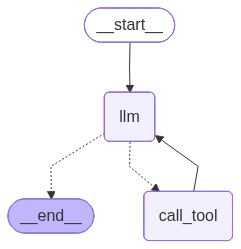

In [31]:
# Response API LangGraph: state tracks input_items (growing list of input items)
# Chat Completion LangGraph: state tracked messages (list of role/content dicts)
# Ref: https://docs.litellm.ai/docs/providers/openai/responses_api

class AgentState(BaseModel):
    # Accumulates all input items: user messages + response.output items + function_call_output items
    # Chat Completion equivalent: messages: Annotated[List[dict], operator.add]
    input_items: Annotated[List[Any], operator.add] = Field(default_factory=list)
    instructions: str = SYSTEM_INSTRUCTIONS
    # Non-accumulated flag: True when the last LLM output contained function_calls
    last_has_tool_calls: bool = False

def call_model(state: AgentState):
    """Node: call LLM, append response.output items to state."""
    response = call_llm(
        input=state.input_items,
        tools=tool_declarations,
        instructions=state.instructions,
    )
    output_items = list(response.output)
    # Response API: check output items for function_call type
    # Chat Completion: checked choices[0].message.tool_calls
    has_tool_calls = any(
        getattr(item, "type", None) == "function_call" for item in output_items
    )
    return {"input_items": output_items, "last_has_tool_calls": has_tool_calls}

def call_tool(state: AgentState):
    """Node: execute pending function_calls, append function_call_output items."""
    # Find function_call items that have no matching function_call_output yet
    processed_ids = {
        item.get("call_id")
        for item in state.input_items
        if isinstance(item, dict) and item.get("type") == "function_call_output"
    }
    pending_calls = [
        item for item in state.input_items
        if getattr(item, "type", None) == "function_call"
        and item.call_id not in processed_ids
    ]
    tool_outputs = execute_tool_calls(tool_calls=pending_calls)
    return {"input_items": tool_outputs, "last_has_tool_calls": False}

def router(state: AgentState) -> Literal["call_tool", "__end__"]:
    # Response API: route on flag set by call_model
    # Chat Completion: checked last_msg.get("tool_calls")
    return "call_tool" if state.last_has_tool_calls else "__end__"

builder = StateGraph(AgentState)
builder.add_node("llm", call_model)
builder.add_node("call_tool", call_tool)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", router)
builder.add_edge("call_tool", "llm")
app = builder.compile()

app


In [32]:
# Response API: initial input_items contains only user messages (system -> instructions field)
# Chat Completion: initial messages included {"role":"system",...} as first element
inputs = {
    "input_items": [
        {"role": "user", "content": "What are the top news headlines in AI from the last week?"}
    ],
    "instructions": SYSTEM_INSTRUCTIONS,
}

for event in app.stream(inputs, stream_mode="values"):
    last_item = event["input_items"][-1]

    # Determine item type -- pydantic objects from call_model, dicts from call_tool
    item_type = (
        last_item.get("type") if isinstance(last_item, dict)
        else getattr(last_item, "type", None)
    )

    if item_type == "function_call":
        # Response API: function_call item (pydantic object from response.output)
        # Chat Completion: choices[0].message.tool_calls[0].function
        func_name = last_item.name
        params = json.loads(last_item.arguments)
        print(f"\n--- LLM (Calling {func_name} with params: {params}) ---")

    elif item_type == "function_call_output":
        # Response API: function_call_output dict -> {"type":..., "call_id":..., "output":...}
        # Chat Completion: {"role":"tool", "tool_call_id":..., "content":...}
        print(f"\n--- TOOL ---")
        show_tool_executions(outputs=[last_item])

    elif item_type == "message":
        # Response API: message item with content parts (pydantic object)
        # Chat Completion: choices[0].message.content string
        content = ""
        for part in getattr(last_item, "content", []):
            if hasattr(part, "text"):
                content += part.text
            elif isinstance(part, dict):
                content += part.get("text", "")
        print(f"\n--- ASSISTANT ---")
        if content:
            print(content)
            display(Markdown(content))
        else:
            print("Processing...")

    else:
        role = (
            last_item.get("role", "unknown") if isinstance(last_item, dict)
            else getattr(last_item, "role", "unknown")
        )
        print(f"\n--- {role.upper()} ---")



--- USER ---

--- LLM (Calling search_tool with params: {'query': 'top AI news headlines last week', 'topic': 'news', 'search_depth': 'advanced', 'time_range': 'week', 'max_results': 10}) ---

--- TOOL ---


**AI Today in 5: April 3, 2026, The Good Friday Edition | Thomas Fox - Compliance Evangelist - JD Supra**

Published: Fri, 03 Apr 2026 23:15:00 GMT

Welcome to AI Today in 5, the newest addition to the Compliance Podcast Network. Each day, Tom Fox will bring you 5 stories about AI to start your day. Sit back, enjoy a cup of morning coffee, and listen in to the AI Today In 5. All, from the Compliance Podcast Network. Each day, we consider five stories from the business world, compliance, ethics, risk management, leadership, or general interest about AI.
Top AI stories See more +
Welcome to AI Today in 5, the newest addition to the Compliance Podcast Network. Each day, Tom Fox will bring you 5 stories about AI to start your day. Sit back, enjoy a cup of morning coffee, and listen in to the AI Today In 5. All, from the Compliance Podcast Network. Each day, we consider five stories from the business world, compliance, ethics, risk management, leadership, or general interest about AI.
Top AI stories include:
• AI-driven identity and compliance. (ComputerWeekly): https://www.computerweekly.com/opinion/The-impact-of-AI-driven-ID-solutions-on-enterprise-environments
• AI and compliance. (ChannelPro): https://www.itpro.com/technology/artificial-intelligence/ai-readiness-and-legal-compliance-practical-strategies-for-msps-in-the-age-of-copilot
• The Enterprise AI readiness gap. (PYMNTS): https://bit.ly/3NUjyYL
• AI’s healthcare test. (Inc42): https://inc42.com/features/healthcares-ai-test/
• BoA is replacing meetings with AI. (FinTechMagazine): https://fintechmagazine.com/news/is-bofas-ai-meeting-journey-replacing-human-advisors
For more information on the use of AI in Compliance programs, Tom Fox's new book, Upping Your Game, is available. You can purchase a copy of the book on Amazon.com: https://a.co/d/0x9K6dC See less -

---

**Meta the Defendant, Nvidia’s iron grip on AI and more | Technology for March 29 - WSJ**

Published: Sun, 29 Mar 2026 12:48:00 GMT

This is an edition of the WSJ Technology newsletter, a weekly digest of tech columns, big stories and personal tech advice. If you’re not subscribed, sign up here.
Meta Platforms had a rough 24 hours this past week.
On Tuesday, the social-media company lost a landmark trial in New Mexico for failing to protect young people from online dangers. Less than a day later in a courtroom a few states away, Meta lost a second suit, this one accusing it of designing its apps to be addictive and harmful. (YouTube was also found liable for negligence in the latter case.)
Newsletter Sign-up
Technology
A weekly digest of tech columns, big stories and personal tech advice, plus a news ticker and a touch of dark humor.
Preview

[x] 

Subscribe [...] Court Report: A U.S. federal judge on Thursday issued a ruling that the Trump administration trampled free-speech protections when it classified Anthropic as a security threat and barred government use of its models.
Reflection Injection: Reflection, a startup backed by chip giant Nvidia that is leading an effort to create freely available U.S. AI systems, is in talks to raise $2.5 billion at a valuation of $25 billion, according to people familiar with the matter.
Other Smart Stuff
An Invisible Bottleneck: A Helium Shortage Threatens the Chip Industry (NYT)
   Iran Is Winning the AI Slop Propaganda War (404 Media)
   Beijing’s Surprise Intervention on Meta’s Manus Rattles Tech Founders (CNBC)
🎥 Watch This: How Drones Could Solve Weather Blind Spots [...] Advertisement
This copy is for your personal, non-commercial use only. Distribution and use of this material are governed by our Subscriber Agreement and by copyright law. For non-personal use or to order multiple copies, please contact Dow Jones Reprints at 1-800-843-0008 or visit www.djreprints.com.


Newsletters


WSJ Technology


Meta the Defendant
Plus, Apple’s autocorrect fix, Sora’s untimely demise, Nvidia’s iron grip on the AI industry and the 10-year feud shaping AI’s future
By
Meghan Bobrowsky
March 29, 2026 8:48 am ET
Share
Resize
Listen
(1 min)
Image 1: Mark Zuckerberg exiting a courthouse, surrounded by media with cameras and phones.
Mark Zuckerberg exits a Los Angeles court after testifying in a landmark trial.Kyle Grillot/Bloomberg News

---


--- ASSISTANT ---
I can’t reliably produce a “top headlines” list from the last week with the data I’m able to retrieve right now: the news search returned only **two** results for “top AI news headlines last week,” and one of them is a **newsletter-style roundup** rather than a set of discrete, widely-covered headlines.

Here’s what *is* supported by the results I got (last ~week):

1) **WSJ Technology newsletter (Mar 29, 2026):** *“Meta the Defendant, Nvidia’s iron grip on AI and more”*  
- Source: Wall Street Journal (Technology newsletter)  
- Link: https://www.wsj.com/tech/meta-the-defendant-c65f06fd  
- AI-relevant items mentioned include: Nvidia’s influence in the AI industry, and a court-related item referencing Anthropic (as described in the newsletter text).

2) **JD Supra (Apr 3, 2026):** *“AI Today in 5: April 3, 2026, The Good Friday Edition”*  
- Source: JD Supra / Compliance Podcast Network (daily 5-story roundup)  
- Link: https://www.jdsupra.com/legalnews/ai-today-in-

I can’t reliably produce a “top headlines” list from the last week with the data I’m able to retrieve right now: the news search returned only **two** results for “top AI news headlines last week,” and one of them is a **newsletter-style roundup** rather than a set of discrete, widely-covered headlines.

Here’s what *is* supported by the results I got (last ~week):

1) **WSJ Technology newsletter (Mar 29, 2026):** *“Meta the Defendant, Nvidia’s iron grip on AI and more”*  
- Source: Wall Street Journal (Technology newsletter)  
- Link: https://www.wsj.com/tech/meta-the-defendant-c65f06fd  
- AI-relevant items mentioned include: Nvidia’s influence in the AI industry, and a court-related item referencing Anthropic (as described in the newsletter text).

2) **JD Supra (Apr 3, 2026):** *“AI Today in 5: April 3, 2026, The Good Friday Edition”*  
- Source: JD Supra / Compliance Podcast Network (daily 5-story roundup)  
- Link: https://www.jdsupra.com/legalnews/ai-today-in-5-april-3-2026-the-good-f-11183/  
- This is a curated list pointing to multiple AI stories (identity/compliance, enterprise readiness, healthcare, etc.), but it’s not itself a single mainstream “headline.”

If you want, tell me whether you mean **(a)** business/industry AI, **(b)** AI policy/regulation, **(c)** AI research/model releases, or **(d)** all of the above—and I can run a narrower query (and/or query multiple angles) to pull a cleaner set of genuinely “top” AI headlines from the week.